# ModelObsCompare — Sverdrups workflow tour

A guided run of `moc_py` on the data that is **actually on disk**. Sverdrups
Glacier (NW Greenland) is the one place in the configured folders where a
gridded observation subset and a redrawn flowline cover the same ice, and the
exported ISSM model reaches it too:

| what | file | extent |
|---|---|---|
| obs grid | `SentinelMonthly_Sverdrups.nc` | 311×301 px, 72 monthly frames, 2015–2020 |
| flowline | `sverdrups.mat` | 31 points, 0–7.5 km, 111 times, 2015–2024 |
| model | `exported/Model_NW_fric1_Snapshot.nc` | 232,756 vertices, 376 steps, 2007–2022 |

Sections: **1** loaders · **2** ROI · **3** speed map · **4** normalised
variability · **5** per-year table · **6** flowline · **7** model comparison.

Script form of the same tour: `examples/example_sverdrups_workflow.py`.
MATLAB twin: `examples/example_sverdrups_workflow.m` (its model section is off
by default — it would load a multi-GB ISSM `.mat`, where the exported netCDF
read here takes about a second).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np, pandas as pd, matplotlib.pyplot as plt

try:
    import moc_py as mp
except ModuleNotFoundError:          # not pip-installed — add python/ to the path
    sys.path.insert(0, str(Path.cwd().parent))
    import moc_py as mp

OBS_NC      = "SentinelMonthly_Sverdrups.nc"
OBS_FL      = "sverdrups.mat"
MODEL_NC    = "exported/Model_NW_fric1_Snapshot.nc"
MELT_WINDOW = (2019.35, 2019.85)   # May-Sep 2019
TWO_SLICES  = (2019.15, 2019.6)    # late winter -> late summer
POINT_DIST  = 3000.0               # [m] along the flowline
MIN_SPEED   = 20.0                 # [m/yr] below this a ratio is meaningless

plt.rcParams["figure.dpi"] = 100

## 1. The two observation readers

`load_obs_netcdf` reads the netCDF4/HDF5 subset with `h5py` (no `netCDF4` or
`rioxarray` needed) and returns dims `(y, x, time)` with decimal-year time.
`load_obs_flowline` normalises whichever velocity layout the `.mat` happens to
use — here `filteredV` + `vti`.

Nodata is masked to NaN on load: these products declare a useless `_FillValue`
attribute (NaN) and keep the real sentinels elsewhere (`-1` on `vv`, `-2e9` on
`vx`/`vy`). Roughly a third of pixel-frames here are nodata — mostly melange
and open water.

In [2]:
O = mp.load_obs_netcdf(OBS_NC, bands=["vv"])
F = mp.load_obs_flowline(OBS_FL)

t = O.time.values
print(f"obs grid  : {O.sizes['x']}x{O.sizes['y']} px, {t.size} frames "
      f"{t.min():.2f}-{t.max():.2f}, "
      f"{100 * np.isfinite(O['vv'].values).mean():.0f}% of pixel-frames valid")
ft = F.time.values
print(f"flowline  : {F.attrs['name']}, {F.sizes['point']} points "
      f"(0-{F.d.values.max()/1e3:.1f} km), {ft.size} times "
      f"{ft.min():.2f}-{ft.max():.2f} (source {F.attrs['source']})")
O

obs grid  : 311x301 px, 72 frames 2014.96-2020.87, 69% of pixel-frames valid
flowline  : sverdrups.mat, 31 points (0-7.5 km), 111 times 2015.08-2024.95 (source filteredV)


<xarray.Dataset> Size: 27MB
Dimensions:  (y: 301, x: 311, time: 72)
Coordinates:
  * y        (y) float64 2kB -1.495e+06 -1.495e+06 ... -1.555e+06 -1.555e+06
  * x        (x) float64 2kB -3.8e+05 -3.798e+05 ... -3.182e+05 -3.18e+05
  * time     (time) float64 576B 2.015e+03 2.015e+03 ... 2.021e+03 2.021e+03
    time_dt  (time) datetime64[s] 576B 2014-12-16 ... 2020-11-15T12:00:00
Data variables:
    vv       (y, x, time) float32 27MB nan nan nan nan ... 134.9 135.6 132.9
Attributes:
    epsg:          3413
    geotransform:  -380100.0 200.0 0.0 -1494900.0 0.0 -200.0
    file:          /Users/michalea/jupyter/code/SentinelMonthly_Sverdrups.nc
    bands:         vv

## 2. An ROI from the flowline footprint

Any `Roi` round-trips to `.json` (Python) **and** `.exp` (ISSM/MATLAB), so an
ROI made here can be reused by the `moc_*` MATLAB functions and vice versa.

In [3]:
pad = 3000.0
x0, x1 = F.x.values.min() - pad, F.x.values.max() + pad
y0, y1 = F.y.values.min() - pad, F.y.values.max() + pad

roi = mp.Roi(name="sverdrups_trunk", kind="rectangle",
             x=np.array([x0, x1, x1, x0, x0]),
             y=np.array([y0, y0, y1, y1, y0]))
mp.save_roi(roi)                       # rois/sverdrups_trunk.json + .exp
roi = mp.load_roi("sverdrups_trunk")   # read back what was written

Xo, Yo = np.meshgrid(O.x.values, O.y.values)
xmin, xmax, ymin, ymax = roi.bbox
print(f"ROI: {(xmax-xmin)/1e3:.1f} x {(ymax-ymin)/1e3:.1f} km, "
      f"{int(mp.roi_mask(roi, Xo, Yo).sum())} of {Xo.size} grid pixels inside")

ROI: 10.3 x 11.9 km, 3068 of 93611 grid pixels inside


## 3. Where we are

One late-summer frame, with the ROI (red) and the flowline (dashed) on top.
White is nodata — the melange-filled fjord and open water.

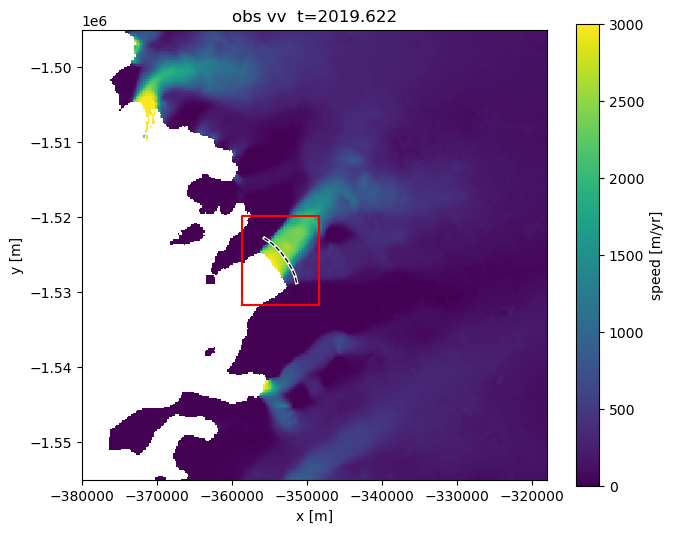

In [4]:
ti = int(np.argmin(np.abs(t - 2019.6)))

fig, ax = plt.subplots(figsize=(7.5, 6))
mp.plot_map(O, band="vv", tindex=ti, ax=ax, clim=(0, 3000), roi=roi)
ax.plot(F.x.values, F.y.values, "w-", lw=2.5)
ax.plot(F.x.values, F.y.values, "k--", lw=1)
plt.show()

## 4a. Normalised variability over a window

`velocity_variance` reduces the time axis to a per-pixel **spread** (here the
peak-to-peak range over May–Sep 2019) and a per-pixel **reference** speed (the
mean over the same window). The ratio `norm = spread / reference` is
dimensionless, so a pixel is comparable with its neighbours as a *fraction of
relative change* rather than an absolute magnitude change.

Compare the two panels: the absolute range (right) just re-draws the fast
trunk, while the relative map (left) says where the ice changed most **for its
own speed**.

`min_speed` is not optional on this data — drop it and the ROI mean jumps from
~0.4 to ~1.2 as near-stagnant margin pixels divide a few m/yr of noise by a few
m/yr of speed.

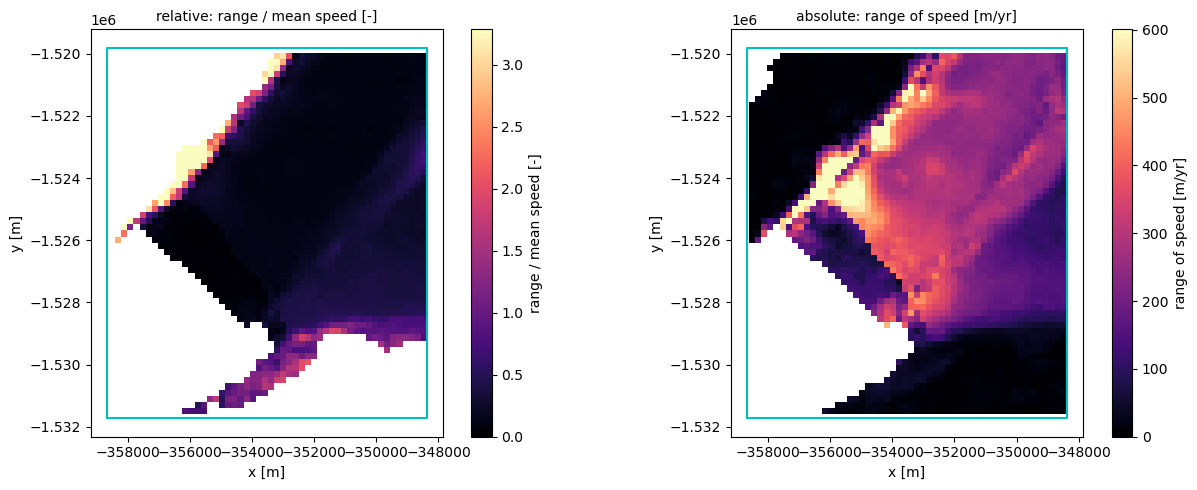

ROI mean 0.43   median 0.19   p90 0.96   over 1803 px


In [5]:
V = mp.velocity_variance(O, roi, trange=MELT_WINDOW, min_count=3, min_speed=MIN_SPEED)

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
mp.plot_variance(V, "norm",   ax=axs[0], roi=roi, title="relative: range / mean speed [-]")
mp.plot_variance(V, "spread", ax=axs[1], roi=roi, title="absolute: range of speed [m/yr]")
fig.tight_layout(); plt.show()

print(f"ROI mean {V.attrs['norm_mean']:.2f}   median {V.attrs['norm_median']:.2f}   "
      f"p90 {V.attrs['norm_p90']:.2f}   over {V.attrs['npix']} px")

## 4b. Between two individual time slices

Pass `times=` instead of `trange=` and the nearest frame to each date is used.
With exactly two frames the result also carries a **signed** change field
(`change`, `norm_change`), drawn on a diverging scale centred on zero: red is
speed-up, blue slow-down.

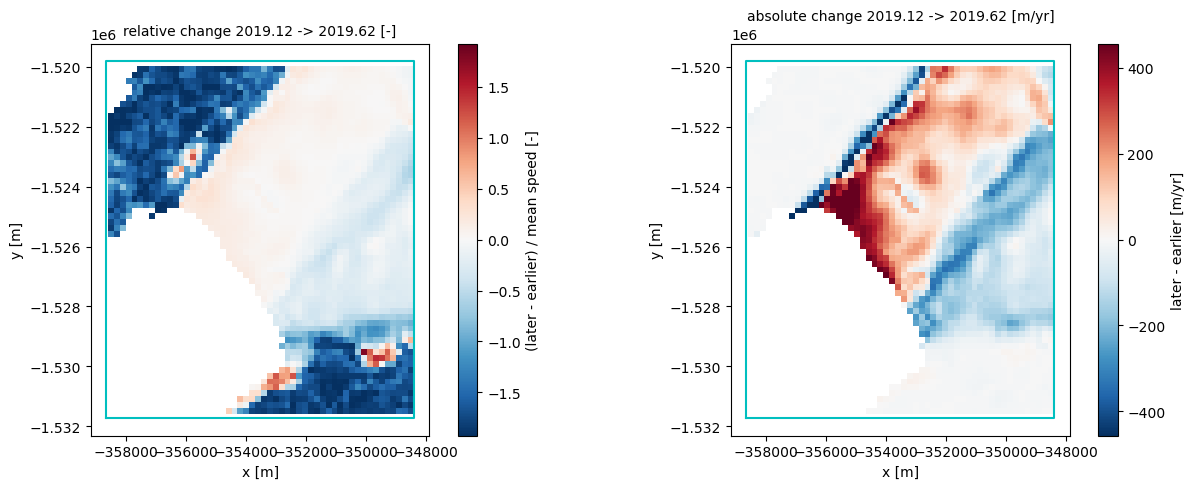

late winter (2019.12) -> late summer (2019.62): mean |change| = 66% of local speed


In [6]:
V2 = mp.velocity_variance(O, roi, times=TWO_SLICES)
t0, t1 = V2.time.values

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
mp.plot_variance(V2, "norm_change", ax=axs[0], roi=roi,
                 title=f"relative change {t0:.2f} -> {t1:.2f} [-]")
mp.plot_variance(V2, "change", ax=axs[1], roi=roi,
                 title=f"absolute change {t0:.2f} -> {t1:.2f} [m/yr]")
fig.tight_layout(); plt.show()

print(f"late winter ({t0:.2f}) -> late summer ({t1:.2f}): "
      f"mean |change| = {100*V2.attrs['norm_mean']:.0f}% of local speed")

## 4c. Robust, record-long, and how much data backs it

`statistic="iqr"` with `normalize="median"` is insensitive to a single bad
frame; `min_count=24` demands at least two years' worth of valid frames per
pixel. The `count` map shows where that bites — the melange-filled fjord mouth
has very few valid frames, which is exactly the region to distrust.

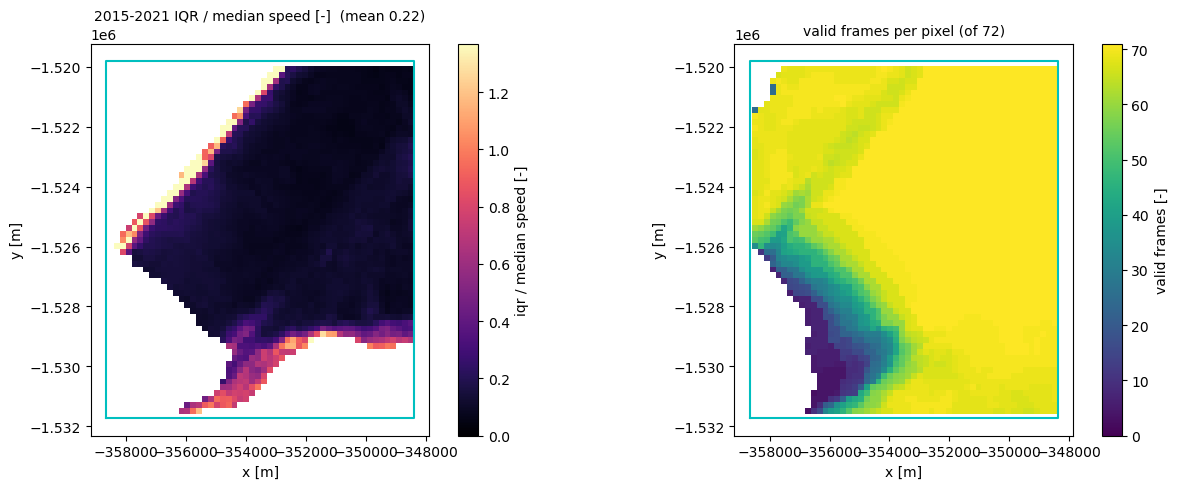

In [7]:
Vr = mp.velocity_variance(O, roi, statistic="iqr", normalize="median",
                          min_speed=MIN_SPEED, min_count=24)

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
mp.plot_variance(Vr, "norm", ax=axs[0], roi=roi,
                 title=f"{t.min():.0f}-{t.max():.0f} IQR / median speed [-]"
                       f"  (mean {Vr.attrs['norm_mean']:.2f})")
mp.plot_variance(Vr, "count", ax=axs[1], roi=roi,
                 title=f"valid frames per pixel (of {t.size})")
fig.tight_layout(); plt.show()

## 5. Melt season, year by year

The same call in a loop. `norm_mean` is pulled up by the noisy tail, so the
median is the number to quote; 2019 stands out on both.

In [8]:
rows = []
for yr in range(int(np.ceil(t.min())), int(np.floor(t.max())) + 1):
    V_yr = mp.velocity_variance(O, roi, trange=(yr + 0.25, yr + 0.85),
                                min_count=3, min_speed=MIN_SPEED)
    a = V_yr.attrs
    rows.append({"year": yr, "frames": a["nframes"], "px": a["npix"],
                 "mean rel. [%]": 100 * a["norm_mean"],
                 "median rel. [%]": 100 * a["norm_median"],
                 "mean range [m/yr]": a["spread_mean"]})

pd.DataFrame(rows).set_index("year").round(1)

,frames,px,mean rel. [%],median rel. [%],mean range [m/yr]
year,,,,,
2015,7,2080,27.1,14.5,155.5
2016,7,2049,39.6,15.7,170.5
2017,7,1977,34.3,17.1,211.1
2018,7,1894,34.8,15.2,203.6
2019,7,1807,44.2,19.4,189.6
2020,7,1756,38.8,18.5,182.9


## 6. The flowline

Left: observed speed as a distance–time image. Right: the series at one point,
with the nearest pixel of the gridded product overlaid — an independent check
that the two readers agree where they overlap. They track each other closely
through 2020; after that only the flowline file has data.

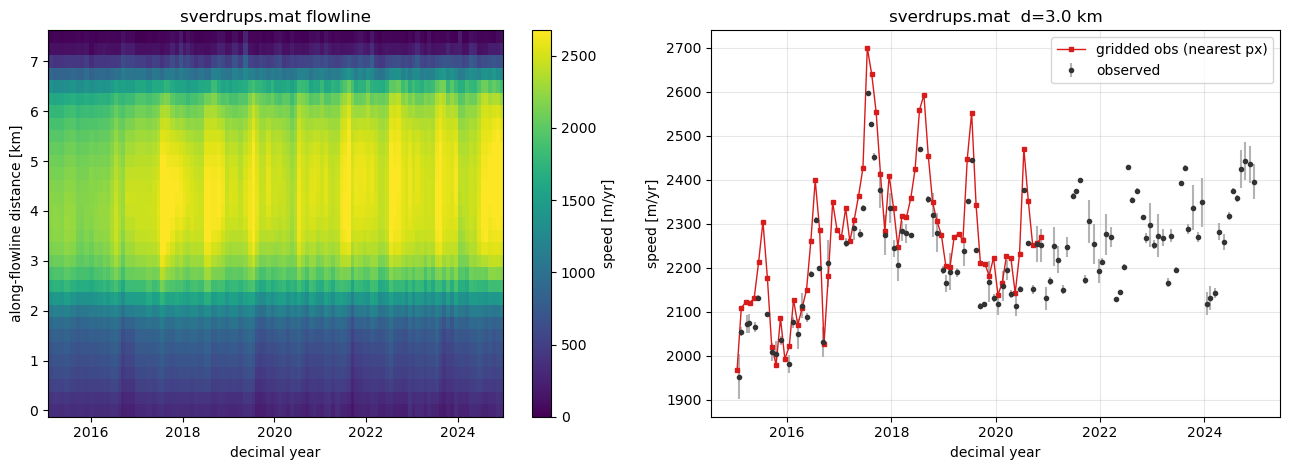

In [9]:
k = int(np.argmin(np.abs(F.d.values - POINT_DIST)))

fig, axs = plt.subplots(1, 2, figsize=(13, 4.8))
mp.plot_flowline(F, mode="hovmoller", ax=axs[0])
mp.plot_timeseries(F, point=k, ax=axs[1], use_datetime=False)

ci = int(np.argmin(np.abs(O.x.values - float(F.x.values[k]))))
ri = int(np.argmin(np.abs(O.y.values - float(F.y.values[k]))))
axs[1].plot(O.time.values, O["vv"].isel(x=ci, y=ri).values, "s-", ms=3,
            color="#d81b1b", lw=1, label="gridded obs (nearest px)")
axs[1].legend()
fig.tight_layout(); plt.show()

## 7. The model

`load_model` reads the neutral netCDF written by `moc_export_model.m` — mesh,
triangulation and velocity time series — and interpolates it with
`matplotlib.tri`, the same P1 linear interpolation as ISSM's
`InterpFromMesh2d`. The 2.8 GB file loads in about a second, which is why this
section runs by default here and not in the MATLAB tour.

In [10]:
M = mp.load_model(MODEL_NC)
print(f"{M.x.size} vertices, {M.elements.shape[0]} elements, "
      f"{M.time.size} steps {M.time.min():.2f}-{M.time.max():.2f}")

232756 vertices, 465007 elements, 376 steps 2007.01-2022.00


### 7a. Spatial difference (model − obs)

Both fields are regridded onto the same regular grid over the ROI before
differencing. The model runs fast on the southern trunk and slow along the
northern shear margin.

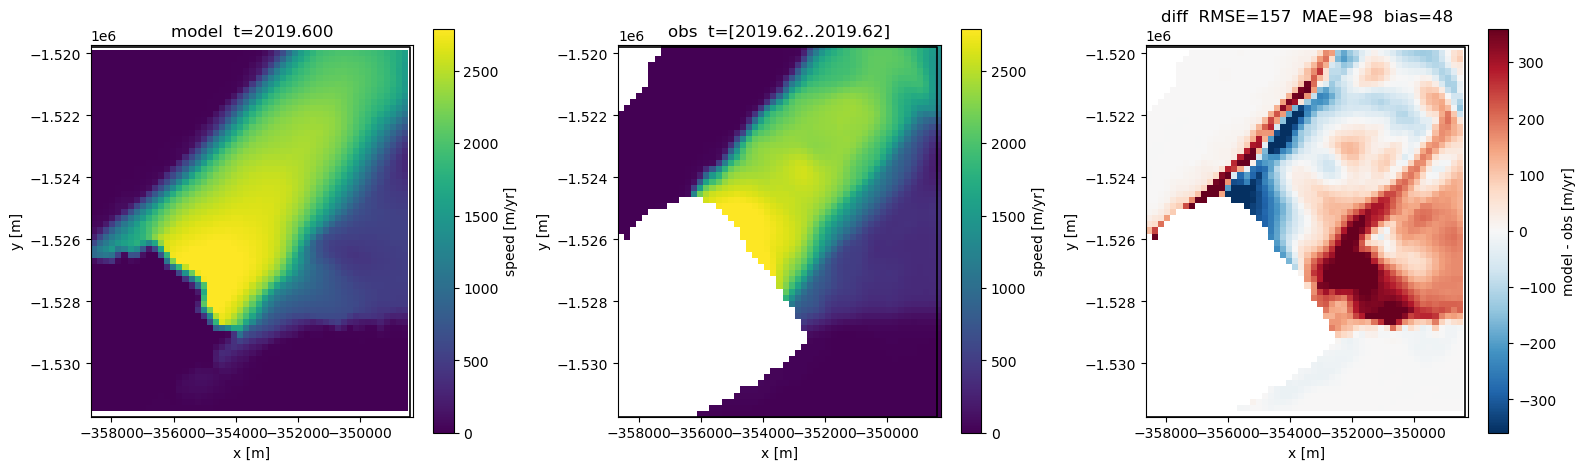

bias 48   RMSE 157   MAE 98 m/yr over 2227 px


In [11]:
D = mp.spatial_diff(M, O, roi, time=2019.6, obswindow=0.05)
mp.plot_diff(D, roi=roi)
plt.show()

print(f"bias {D.attrs['bias']:.0f}   RMSE {D.attrs['rmse']:.0f}   "
      f"MAE {D.attrs['mae']:.0f} m/yr over {D.attrs['n']} px")

### 7b. Along the flowline, and at one point

The profile shows where the mismatch sits (the lower 3 km); the paired series
shows *when* — the modelled seasonal cycle grows after 2017 while the
observations flatten.

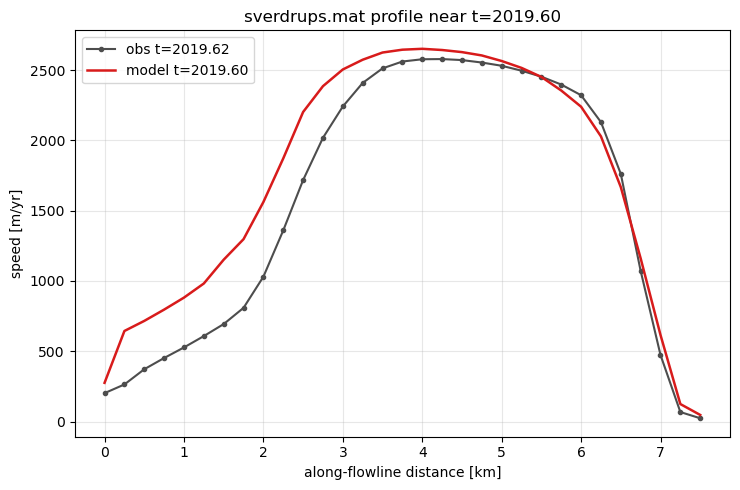

In [12]:
Fmod = mp.model_flowline(M, F)

fig, ax = plt.subplots(figsize=(7.5, 5))
mp.plot_flowline(F, mode="profile", time=2019.6, model=Fmod, ax=ax)
fig.tight_layout(); plt.show()

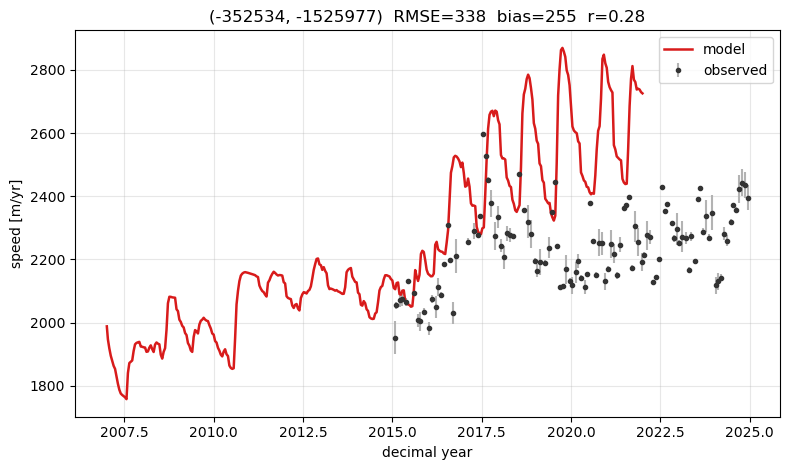

at d=3.0 km: bias 255   RMSE 338 m/yr   r 0.28   over 75 paired times


In [13]:
C = mp.compare_timeseries(M, F, dist=POINT_DIST)

fig, ax = plt.subplots(figsize=(8, 4.8))
mp.plot_compare(C, ax=ax, use_datetime=False)
fig.tight_layout(); plt.show()

print(f"at d={POINT_DIST/1e3:.1f} km: bias {C.stats['mean']:.0f}   "
      f"RMSE {C.stats['rmse']:.0f} m/yr   r {C.stats['r']:.2f}   "
      f"over {C.stats['n']} paired times")

## Where to go next

- Re-run any section on another glacier by changing `OBS_NC` / `OBS_FL` — the
  Sverdrups netCDFs also come in six-day (`SentinelSixDay_Sverdrups.nc`) and
  CSK flavours, and `nansen.mat` is the other flowline inside this grid.
- `mp.velocity_variance` options: `statistic` (`range`/`std`/`iqr`/`mad`),
  `normalize` (`mean`/`median`/`first`/`max`/`none`), `min_count`, `min_speed`.
- Same tour as a script: `python examples/example_sverdrups_workflow.py
  --save-figs`; in MATLAB: `example_sverdrups_workflow`.